In [7]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DATASET_ZIP = "/content/drive/MyDrive/dataset_blood_group.zip"
EXTRACT_ROOT = "/content"
DATASET_DIR = "/content/dataset_blood_group"

!ls /content/drive/MyDrive
!unzip -q "$DRIVE_DATASET_ZIP" -d "$EXTRACT_ROOT"
!ls /content

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
'Colab Notebooks'   dataset_blood_group.zip   resnt50.keras
replace /content/dataset_blood_group/A+/cluster_0_1001.BMP? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
dataset_blood_group  drive  sample_data


In [8]:
import os
DATASET_DIR = os.environ.get('DATASET_DIR', DATASET_DIR)
print(f"Using dataset path: {DATASET_DIR}")

Using dataset path: /content/dataset_blood_group


In [36]:
import os
import random
import math
from pathlib import Path
from pprint import pprint


import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm


import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import random_split, DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid


# Optional evaluation helpers
from sklearn.metrics import classification_report, confusion_matrix

In [37]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


# Choose dataset path here or rely on an environment variable
# Replace below with your actual dataset path if not using Kaggle
DATASET_DIR = '/content/dataset_blood_group'

In [38]:
BATCH_SIZE = 32
IMAGE_SIZE = 224 # Swin default
NUM_WORKERS = 4
EPOCHS = 12
LR = 2e-4
WEIGHT_DECAY = 1e-4
GRAD_CLIP = 1.0


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [39]:
# =================== 3. Dataset & Transforms ===================

if not os.path.exists(DATASET_DIR):
  raise FileNotFoundError(
  f"Dataset directory not found: {DATASET_DIR}\nPlease set DATASET_DIR to the folder that contains class subfolders (ImageFolder layout)."
   )


# Use ImageNet normalization since we'll use pretrained weights
transform = transforms.Compose([
transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
transforms.ToTensor(),
transforms.Normalize(mean=[0.485, 0.456, 0.406],
std=[0.229, 0.224, 0.225])
])

In [40]:
# Load with ImageFolder and then split into train/val/test
full_dataset = datasets.ImageFolder(DATASET_DIR, transform=transform)
NUM_CLASSES = len(full_dataset.classes)
print(f"Found {len(full_dataset)} images across {NUM_CLASSES} classes: {full_dataset.classes}")


# Split sizes (you can change val_size/test_size as needed)
TOTAL = len(full_dataset)
VAL_SIZE = min(1000, TOTAL // 10)
TEST_SIZE = min(1000, TOTAL // 10)
TRAIN_SIZE = TOTAL - VAL_SIZE - TEST_SIZE


if TRAIN_SIZE <= 0:
  raise RuntimeError("Not enough images to create train/val/test splits with the chosen sizes.")


train_ds, val_ds, test_ds = random_split(full_dataset, [TRAIN_SIZE, VAL_SIZE, TEST_SIZE])
print(f"Split -> train: {len(train_ds)}, val: {len(val_ds)}, test: {len(test_ds)}")

Found 6000 images across 8 classes: ['A+', 'A-', 'AB+', 'AB-', 'B+', 'B-', 'O+', 'O-']
Split -> train: 4800, val: 600, test: 600


In [41]:
# Create DataLoaders
def make_loader(ds, batch_size=BATCH_SIZE, shuffle=False):
 return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                   num_workers=NUM_WORKERS, pin_memory=True)


train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = make_loader(val_ds, batch_size=BATCH_SIZE*2, shuffle=False)
test_loader = make_loader(test_ds, batch_size=BATCH_SIZE*2, shuffle=False)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [42]:
# Sanity visualize a batch
def show_batch(dl, classes=full_dataset.classes):
  for imgs, labels in dl:
      grid = make_grid(imgs[:16], nrow=8)
      img_np = grid.permute(1, 2, 0).cpu().numpy()
# Undo normalization for display
      mean = np.array([0.485, 0.456, 0.406])
      std = np.array([0.229, 0.224, 0.225])
      img_np = std * img_np + mean
      img_np = np.clip(img_np, 0, 1)
      plt.figure(figsize=(12, 6))
      plt.imshow(img_np)
      plt.axis('off')
      break

In [43]:
# ================ 4. Device wrapper ================

def to_device(data, device):
  if isinstance(data, (list, tuple)):
     return [to_device(x, device) for x in data]
  return data.to(device, non_blocking=True)

class DeviceDataLoader:
#"""Wrap a dataloader to move data to device automatically"""
  def __init__(self, dl, device):
       self.dl = dl
       self.device = device
  def __iter__(self):
      for b in self.dl:
         yield to_device(b, self.device)
  def __len__(self):
      return len(self.dl)


train_loader = DeviceDataLoader(train_loader, DEVICE)
val_loader = DeviceDataLoader(val_loader, DEVICE)
test_loader = DeviceDataLoader(test_loader, DEVICE)

In [44]:
# ======================
# 5. Load Swin Transformer (with fallback)
# ======================

def load_swin(num_classes):
    """Try to load torchvision's Swin; if not available, try timm.
    Returns model (on CPU) and backend string."""
    try:
        from torchvision.models import swin_t, Swin_T_Weights
        print("Loading torchvision.models.swin_t pretrained weights...")
        weights = Swin_T_Weights.DEFAULT
        model = swin_t(weights=weights)

        # Replace classifier head
        if hasattr(model, 'head') and isinstance(model.head, nn.Linear):
            in_f = model.head.in_features
            model.head = nn.Linear(in_f, num_classes)
        elif hasattr(model, 'fc') and isinstance(model.fc, nn.Linear):
            in_f = model.fc.in_features
            model.fc = nn.Linear(in_f, num_classes)

        backend = 'torchvision'
        return model, backend

    except Exception as e_torch:
        print("torchvision Swin not available or failed:", str(e_torch))

        try:
            import timm
            print("Loading timm swin_tiny_patch4_window7_224 pretrained weights...")
            model = timm.create_model("swin_tiny_patch4_window7_224", pretrained=True)

            if hasattr(model, 'head') and isinstance(model.head, nn.Linear):
                in_f = model.head.in_features
                model.head = nn.Linear(in_f, num_classes)
            elif hasattr(model, 'fc') and isinstance(model.fc, nn.Linear):
                in_f = model.fc.in_features
                model.fc = nn.Linear(in_f, num_classes)
            elif hasattr(model, 'num_features'):
                nf = model.num_features
                model.head = nn.Linear(nf, num_classes)

            backend = 'timm'
            return model, backend

        except Exception as e_timm:
            print("timm not available or failed:", str(e_timm))
            raise RuntimeError(
                "No Swin Transformer available. Install torchvision with Swin support "
                "or install timm (`pip install timm`)."
            )

# ✅ Use NUM_CLASSES (uppercase), not num_classes
print("Loading Swin Transformer model (may take a while the first time)...")
model_cpu, backend = load_swin(NUM_CLASSES)  # <--- FIXED HERE
print("Backend used:", backend)

# Move to device
model = to_device(model_cpu, DEVICE)
print(model)

Loading Swin Transformer model (may take a while the first time)...
Loading torchvision.models.swin_t pretrained weights...
Backend used: torchvision
SwinTransformer(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): Permute()
      (2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
    )
    (1): Sequential(
      (0): SwinTransformerBlock(
        (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (attn): ShiftedWindowAttention(
          (qkv): Linear(in_features=96, out_features=288, bias=True)
          (proj): Linear(in_features=96, out_features=96, bias=True)
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (0): Linear(in_features=96, out_features=384, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linea

In [45]:
# ================ 6. Training Utilities ================
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))

class ImageClassificationBase(nn.Module):
    def training_step(self, batch):
        images, labels = batch
        out = self(images)
        loss = F.cross_entropy(out, labels)
        return loss

    def validation_step(self, batch):
        images, labels = batch
        out = self(images)
        loss = F.cross_entropy(out, labels)
        acc = accuracy(out, labels)
        return {"val_loss": loss.detach(), "val_acc": acc}

    def validation_epoch_end(self, outputs):
        batch_losses = [x["val_loss"] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()
        batch_accs = [x["val_acc"] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()
        return {"val_loss": epoch_loss.item(), "val_acc": epoch_acc.item()}

    def epoch_end(self, epoch, result):
        print(f"Epoch [{epoch+1}], train_loss: {result['train_loss']:.4f}, val_loss: {result['val_loss']:.4f}, val_acc: {result['val_acc']:.4f}")

# If model doesn't already expose training helper methods, wrap it
if not isinstance(model, ImageClassificationBase):
    class NetWrapper(ImageClassificationBase):
        def __init__(self, backbone):
            super().__init__()
            self.backbone = backbone
        def forward(self, x):
            return self.backbone(x)
    model = NetWrapper(model)
    model = to_device(model, DEVICE)

# Training / evaluation functions
def evaluate(model, val_loader):
    model.eval()
    outputs = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)

def fit(epochs, model, train_loader, val_loader, optimizer, scheduler=None, grad_clip=None):
    history = []
    for epoch in range(epochs):
        model.train()
        train_losses = []
        for batch in train_loader:
            loss = model.training_step(batch)
            train_losses.append(loss)
            loss.backward()

            if grad_clip:
                nn.utils.clip_grad_value_(model.parameters(), grad_clip)

            optimizer.step()
            optimizer.zero_grad()
            if scheduler is not None:
                try:
                    scheduler.step()
                except Exception:
                    pass

        result = evaluate(model, val_loader)
        result['train_loss'] = torch.stack(train_losses).mean().item()
        model.epoch_end(epoch, result)
        history.append(result)
    return history

In [ ]:
# ================ 7. Optimizer & Scheduler ================
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Optional OneCycleLR scheduler
try:
    steps_per_epoch = len(train_loader)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=LR,epochs=EPOCHS,steps_per_epoch=steps_per_epoch)
except Exception:
    scheduler = None

In [47]:
# ================ 8. Run Training ================
print("Starting training...")
history = fit(EPOCHS, model, train_loader, val_loader, optimizer, scheduler, grad_clip=GRAD_CLIP)

Starting training...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch [1], train_loss: 1.4301, val_loss: 0.4213, val_acc: 0.8536
Epoch [2], train_loss: 0.5556, val_loss: 0.3921, val_acc: 0.8411
Epoch [3], train_loss: 0.4634, val_loss: 0.2949, val_acc: 0.8729
Epoch [4], train_loss: 0.3827, val_loss: 0.3914, val_acc: 0.8464
Epoch [5], train_loss: 0.3021, val_loss: 0.3022, val_acc: 0.8870
Epoch [6], train_loss: 0.2358, val_loss: 0.3359, val_acc: 0.8750
Epoch [7], train_loss: 0.1948, val_loss: 0.2506, val_acc: 0.9125
Epoch [8], train_loss: 0.1215, val_loss: 0.2422, val_acc: 0.9203
Epoch [9], train_loss: 0.0717, val_loss: 0.2255, val_acc: 0.9187
Epoch [10], train_loss: 0.0508, val_loss: 0.2065, val_acc: 0.9370
Epoch [11], train_loss: 0.0282, val_loss: 0.2177, val_acc: 0.9307
Epoch [12], train_loss: 0.0267, val_loss: 0.2114, val_acc: 0.9359


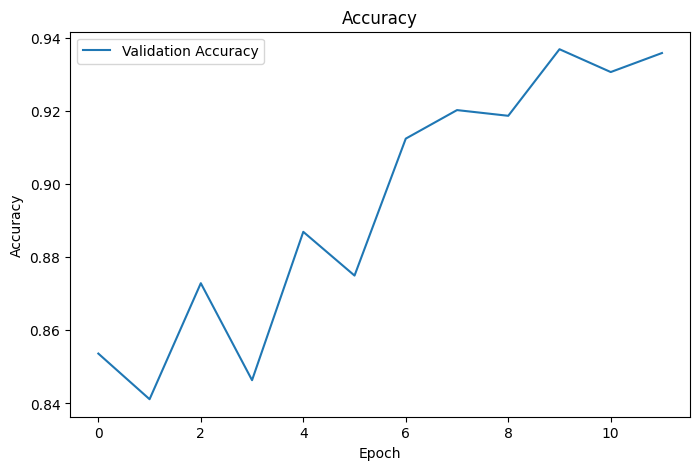

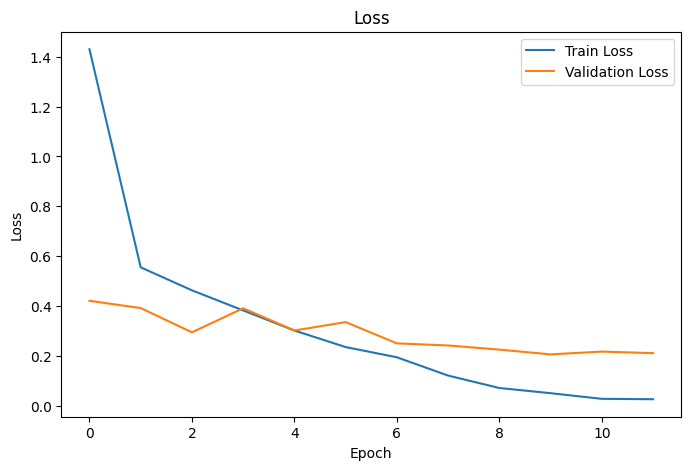

Evaluating on test set...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Test Accuracy: 93.83%

Classification Report:

              precision    recall  f1-score   support

          A+       0.92      0.94      0.93        51
          A-       0.93      0.95      0.94        97
         AB+       0.96      0.95      0.95        76
         AB-       0.91      0.91      0.91        70
          B+       0.95      0.95      0.95        77
          B-       0.96      0.99      0.97        71
          O+       0.93      0.93      0.93        80
          O-       0.95      0.90      0.92        78

    accuracy                           0.94       600
   macro avg       0.94      0.94      0.94       600
weighted avg       0.94      0.94      0.94       600



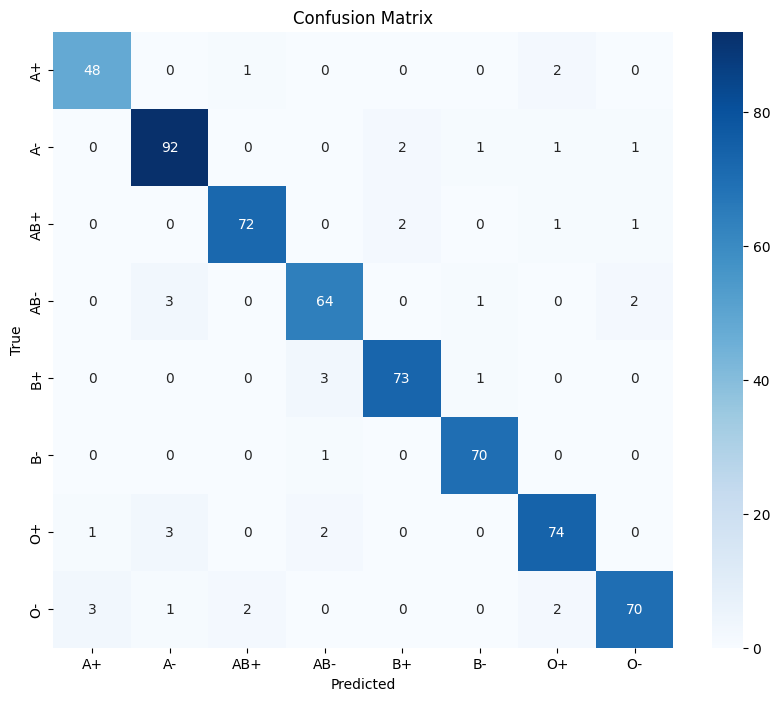

In [51]:
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ================= Plot training history =================

history_df = pd.DataFrame(history)

# Accuracy plot
plt.figure(figsize=(8,5))
plt.plot(history_df['val_acc'], label='Validation Accuracy')
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss plot
plt.figure(figsize=(8,5))
plt.plot(history_df['train_loss'], label='Train Loss')
plt.plot(history_df['val_loss'], label='Validation Loss')
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


# ================= Evaluate model on test set =================

@torch.no_grad()
def evaluate_with_predictions(model, loader):
    model.eval()

    all_preds = []
    all_targets = []

    total = 0
    correct = 0

    for images, labels in loader:
        outputs = model(images)

        _, preds = torch.max(outputs, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(labels.cpu().numpy())

    acc = correct / total

    return np.array(all_preds), np.array(all_targets), acc


print("Evaluating on test set...")

preds, targets, test_acc = evaluate_with_predictions(model, test_loader)

print(f"Test Accuracy: {test_acc*100:.2f}%")


# ================= Classification Report =================

print("\nClassification Report:\n")

print(
    classification_report(
        targets,
        preds,
        target_names=full_dataset.classes
    )
)


# ================= Confusion Matrix =================

cm = confusion_matrix(targets, preds)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=full_dataset.classes,
    yticklabels=full_dataset.classes,
    cmap='Blues'
)

plt.ylabel("True")
plt.xlabel("Predicted")
plt.title("Confusion Matrix")

plt.show()

In [52]:
# Save model
MODEL_PATH = "swin_model_F.pth"
torch.save(model.state_dict(), MODEL_PATH)

print("Model saved successfully:", MODEL_PATH)

Model saved successfully: swin_model_F.pth


In [1]:
import torch
import torch.nn as nn
from torchvision.models import swin_t
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

# ===== Classes =====
classes = ['A+', 'A-', 'AB+', 'AB-', 'B+', 'B-', 'O+', 'O-']

# ===== Wrapper class (same as training) =====
class NetWrapper(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone

    def forward(self, x):
        return self.backbone(x)

# ===== Load backbone =====
backbone = swin_t(weights=None)
backbone.head = nn.Linear(backbone.head.in_features, len(classes))

# Wrap model
model = NetWrapper(backbone)

# ===== Load weights =====
MODEL_PATH = "../../models/swin.pth"

model.load_state_dict(torch.load(MODEL_PATH, map_location="cpu"))
model.eval()

print("Model loaded successfully")

# ===== Transform (same as training) =====
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

# ===== Image path =====
img_path = r"C:\Users\ASUS\Desktop\BD1\dataset\dataset_blood_group\AB+\cluster_4_37.BMP"

img = Image.open(img_path).convert("RGB")

img_tensor = transform(img)

xb = img_tensor.unsqueeze(0)

# ===== Prediction =====
with torch.no_grad():
    outputs = model(xb)
    probs = torch.softmax(outputs, dim=1)

pred_index = torch.argmax(probs, dim=1).item()

prediction = classes[pred_index]
confidence = probs[0][pred_index].item() * 100

print("Prediction:", prediction)
print("Confidence:", confidence)

# ===== Show image =====
plt.imshow(img)
plt.axis('off')
plt.title(f"{prediction} ({confidence:.2f}%)")
plt.imshow(img)
plt.axis("off")

# ===== All probabilities =====
print("\nClass Probabilities:")
for i, cls in enumerate(classes):
    print(f"{cls}: {probs[0][i].item()*100:.2f}%")

Model loaded successfully
Prediction: AB+
Confidence: 99.9998927116394

Class Probabilities:
A+: 0.00%
A-: 0.00%
AB+: 100.00%
AB-: 0.00%
B+: 0.00%
B-: 0.00%
O+: 0.00%
O-: 0.00%


: 